<center>

# **Maestría en Inteligencia Artificial Aplicada**

[![Institution](https://img.shields.io/badge/Instituto-Tecnológico%20de%20Monterrey-1F497D?style=for-the-badge&logo=graduation-cap)](https://tec.mx)
[![Course](https://img.shields.io/badge/Curso-Navegación%20autónoma-FF6B6B?style=for-the-badge&logo=eye)](https://tec.mx)![Activity](https://img.shields.io/badge/Actividad%204.1-Detección%20de%20Señales%20de%20Tránsito-F9AB00?style=for-the-badge&logo=googlecolab)


</center>

### **Profesores**
- **Profesor Titular:** Dr. David Antonio Torres
- **Profesor Asistente:** Mtra. Yetnalezi Quintas Ruiz
---

## **Equipo 01**

<div style="display: flex; justify-content: center; margin: 20px 0;">
  <table style="border-collapse: collapse; font-family: Arial, sans-serif;">
    <thead>
      <tr style="border-bottom: 2px solid #333;">
        <th style="padding: 10px 40px; text-align: center;">Nombre</th>
        <th style="padding: 10px 40px; text-align: center;">Matrícula</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Luis Gabriel Lobato Barajas</td>
        <td style="padding: 8px 40px; text-align: center;">A01797069</td>
      </tr>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Ángel Eduardo Pérez Cruz</td>
        <td style="padding: 8px 40px; text-align: center;">A01797661</td>
      </tr>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Juan Carlos Pérez Nava</td>
        <td style="padding: 8px 40px; text-align: center;">A01795941</td>
      </tr>
      <tr>
        <td style="padding: 8px 40px; text-align: center;">Israel Sánchez Arenas</td>
        <td style="padding: 8px 40px; text-align: center;">A01797385</td>
      </tr>
    </tbody>
  </table>
</div>

## **<font color="#895cf9">Detalles de la Actividad</font>**
- **Título:** Detección de Señales de Tránsito
- **Fecha de entrega:** Junio 07 2026
- **Modalidad:** Equipo

## **<font color="orange">Objetivo del Proyecto</font>**

Comprender el diseño y evaluación de las Redes Neuronales Convolucionales aplicadas a la clasificación de imágenes.

---

## **<font color="red">📚 **Tabla de Contenidos**</font>**

1.  **Librerias utilizadas**
2.  **Funciones adicionales**
3.  **Carga del dataset**
    * Acerca del conjunto de datos
4.  **Creación del dataset de entrenamiento y prueba**
    * Preparación del conjunto de datos
5.  **Creación de la Red Neuronal Convolucional**
    * Data Augmentation
    * Bloques convolucionales
    * Capas de clasificación
    * Compilación
6.  **Entrenamiento**
7.  **Resultados del entrenamiento**
8.  **Evaluación sobre el conjunto de validación**
9.  **Guardado del modelo y metadatos**
    * Carga del modelo
    * Evaluación sobre el conjunto de validación
    * La matriz de confusión
10.  **Referencias**

## **<font color="orange">Librerías utilizadas</font>**

Para el desarrollo de esta actividad, se requiere un conjunto de librerías especializadas que cubren desde la manipulación de datos y el procesamiento de imágenes hasta la construcción y evaluación de modelos de aprendizaje profundo. A continuación se describen las principales herramientas empleadas, agrupadas según su propósito.

### **<font color=" #06bbd8">Librería estándar de Python</font>**

Se utilizan los módulos nativos `os` y `json`, fundamentales para la interacción con el sistema de archivos (como la lectura de rutas y directorios del dataset) y para la carga o almacenamiento de configuraciones y metadatos en formato `JSON`, respectivamente.

### **<font color=" #06bbd8">Manejo de datos y estadísticas</font>**

Para la evaluación del modelo se recurre a `Scikit-learn`, concretamente a `train_test_split` para dividir el dataset en subconjuntos de entrenamiento y prueba de forma reproducible, y a `classification_report` y `confusion_matrix` para obtener métricas detalladas del rendimiento por clase, como precisión, `recall` y `F1-score`.

### **<font color=" #06bbd8">Visualización y procesamiento de imágenes</font>**


`Matplotlib` es la librería principal de visualización, utilizada para graficar curvas de entrenamiento, mostrar ejemplos del dataset y representar resultados.

Para el procesamiento de imágenes a bajo nivel se emplea `OpenCV` (cv2), una librería ampliamente utilizada en visión por computadora que permite realizar operaciones como redimensionamiento, conversión de espacios de color y normalización. De forma complementaria, `Pillow` (PIL) ofrece una interfaz sencilla para la carga y conversión de imágenes antes de transformarlas en arreglos numéricos.

### **<font color=" #06bbd8">Descarga del dataset</font>**

`KaggleHub` es la librería oficial de Kaggle para la descarga programática de datasets directamente desde su plataforma, lo que simplifica la obtención del *GTSRB* sin necesidad de descarga manual.

### **<font color=" #06bbd8">Deep Learning</font>**

El núcleo del modelo se construye sobre `TensorFlow` y su API de alto nivel `Keras`. `TensorFlow` provee el motor de cómputo para el entrenamiento sobre GPU o CPU, mientras que `Keras` simplifica la definición de arquitecturas mediante sus módulos layers y models, que permiten apilar capas convolucionales, de agrupamiento (pooling), de normalización y de clasificación de forma declarativa.

La función `to_categorical` de `keras.utils` se utiliza para convertir las etiquetas numéricas de clase en vectores `one-hot`, formato requerido por la función de pérdida de clasificación multi-clase.

In [ ]:
# ── Librería estándar ─────────────────────────────────────────────────────────
import os
import json

# ── Datos y estadísticas ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (   classification_report
                             ,  confusion_matrix
                             ,  ConfusionMatrixDisplay
                            )

# ── Visualización e imágenes ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm.notebook import tqdm

# ── Deep Learning ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# ── Dataset ───────────────────────────────────────────────────────────────────
import kagglehub

# ── Deep Learning ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical


## **<font color="orange">Funciones adicionales</font>**

Esta función genera un gráfico de barras para visualizar los `F1-scores` por clase, destacando las clases que caen por debajo de un umbral de rendimiento especificado.

In [ ]:
def plot_f1_by_class(report_dict, title, umbral=0.90):

    # ── Extraer clases ────────────────────────────────────────────────────────
    skip = {"accuracy", "macro avg", "weighted avg"}
    names = [k for k in report_dict if k not in skip]

    f1_scores = [report_dict[name]["f1-score"] for name in names]
    colors    = ["#d62728" if f < umbral else "#1f77b4" for f in f1_scores]

    min_f1  = min(f1_scores) * 100
    y_floor = max(0, (int(min_f1 // 5) * 5) - 5)
    y_ceil  = 101

    fig, ax = plt.subplots(figsize=(16, 4))

    ax.bar(
        range(len(names)),
        [f * 100 for f in f1_scores],
        color=colors,
        edgecolor="white",
        linewidth=0.5,
    )

    # ── Líneas de referencia ──────────────────────────────────────────────────
    umbral_pct = umbral * 100
    ax.axhline(umbral_pct, color="red",   linestyle="--",
               linewidth=1, label=f"Meta {umbral_pct:.0f} %")
    ax.axhline(100,           color="green", linestyle="--",
               linewidth=1, label="100 %")

    # ── Etiqueta sobre barras por debajo del umbral ───────────────────────────
    for i, (f, c) in enumerate(zip(f1_scores, colors)):
        if c == "#d62728":
            ax.text(
                i, f * 100 + 0.15,
                f"{f * 100:.1f}",
                ha="center", va="bottom",
                fontsize=7, color="#d62728",
            )

    # ── Ejes y formato ────────────────────────────────────────────────────────
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Clase")
    ax.set_ylabel("F1-score (%)")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=8)
    ax.set_ylim(y_floor, y_ceil)
    ax.legend()
    ax.grid(axis="y", alpha=0.4)

    plt.tight_layout()
    plt.show()

## **<font color="orange">Carga del dataset</font>**

### **<font color=" #06bbd8">Acerca del conjunto de datos</font>**

**GTSRB – German Traffic Sign Recognition Benchmark**

El **GTSRB** es uno de los conjuntos de datos de referencia más utilizados en el campo del reconocimiento de señales de tránsito y, más ampliamente, en tareas de clasificación de imágenes con redes neuronales. Fue introducido como un desafío de clasificación multi-clase en la International Joint Conference on Neural Networks (IJCNN) celebrada en 2011, y desde entonces se ha consolidado como un benchmark estándar para evaluar modelos de visión por computadora en escenarios del mundo real.

El dataset fue recopilado en Alemania por investigadores del *Institut für Neuroinformatik de la Ruhr-Universität Bochum*. Su objetivo fue crear una base de datos lo suficientemente grande, variada y representativa para servir como prueba rigurosa para algoritmos de aprendizaje automático.

**Características clave:**
-   Contiene más de 50,000 imágenes fotográficas de señales de tránsito reales.
-   Las imágenes están distribuidas en 43 categorías distintas.
-   El conjunto de entrenamiento incluye 39,209 imágenes.
-   El conjunto de prueba contiene 12,630 imágenes.

In [ ]:
DATASET_SLUG = "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
owner, name = DATASET_SLUG.split("/")
cache_dir = os.path.expanduser(f"~/.cache/kagglehub/datasets/{owner}/{name}/versions")

if os.path.exists(cache_dir) and os.listdir(cache_dir):
    latest_version = sorted(os.listdir(cache_dir))[-1]
    path = os.path.join(cache_dir, latest_version)
    print(f"Dataset ya localizado en caché (versión {latest_version}): {path}")
else:
    print("Dataset no encontrado en caché, iniciando descarga...")
    path = kagglehub.dataset_download(DATASET_SLUG)
    print(f"Dataset descargado en: {path}")

Dataset no encontrado en caché, iniciando descarga...
Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset descargado en: /kaggle/input/gtsrb-german-traffic-sign


In [ ]:
DATASET_PATH = path
TRAIN_PATH   = os.path.join(DATASET_PATH, "Train")
TEST_PATH    = os.path.join(DATASET_PATH, "Test")

IMG_SIZE     = 32
NUM_CLASSES  = 43

for folder, label in [(TRAIN_PATH, "Train"), (TEST_PATH, "Test")]:
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Carpeta '{label}' no encontrada en: {folder}")

print("=" * 52)
print("   Cargando imágenes de entrenamiento")
print("=" * 52)
print(f"  Ruta Train  : {TRAIN_PATH}")
print(f"  Clases      : {NUM_CLASSES}")
print(f"  Tamaño img  : {IMG_SIZE}x{IMG_SIZE} px")
print()

images, labels = [], []
class_counts   = {}

for class_id in range(NUM_CLASSES):
    class_path = os.path.join(TRAIN_PATH, str(class_id))
    img_files  = os.listdir(class_path)
    class_counts[class_id] = len(img_files)

    for img_name in img_files:
        img = cv2.imread(os.path.join(class_path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(class_id)

    print(f"  [{class_id + 1:>2}/{NUM_CLASSES}] Clase {class_id:>2}: {len(img_files):>4} imágenes")

X = np.array(images, dtype="float32") / 255.0
y = np.array(labels)

clase_max = max(class_counts, key=class_counts.get)
clase_min = min(class_counts, key=class_counts.get)

print()
print("=" * 52)
print("   Resumen de carga")
print("=" * 52)
print(f"  Total imágenes  : {len(images):,}")
print(f"  Shape X         : {X.shape}  dtype: {X.dtype}")
print(f"  Shape y         : {y.shape}")
print(f"  Clase con más   : clase {clase_max} ({class_counts[clase_max]:,} imgs)")
print(f"  Clase con menos : clase {clase_min} ({class_counts[clase_min]:,} imgs)")
print("=" * 52)

   Cargando imágenes de entrenamiento
  Ruta Train  : /kaggle/input/gtsrb-german-traffic-sign/Train
  Clases      : 43
  Tamaño img  : 32x32 px

  [ 1/43] Clase  0:  210 imágenes
  [ 2/43] Clase  1: 2220 imágenes
  [ 3/43] Clase  2: 2250 imágenes
  [ 4/43] Clase  3: 1410 imágenes
  [ 5/43] Clase  4: 1980 imágenes
  [ 6/43] Clase  5: 1860 imágenes
  [ 7/43] Clase  6:  420 imágenes
  [ 8/43] Clase  7: 1440 imágenes
  [ 9/43] Clase  8: 1410 imágenes
  [10/43] Clase  9: 1470 imágenes
  [11/43] Clase 10: 2010 imágenes
  [12/43] Clase 11: 1320 imágenes
  [13/43] Clase 12: 2100 imágenes
  [14/43] Clase 13: 2160 imágenes
  [15/43] Clase 14:  780 imágenes
  [16/43] Clase 15:  630 imágenes
  [17/43] Clase 16:  420 imágenes
  [18/43] Clase 17: 1110 imágenes
  [19/43] Clase 18: 1200 imágenes
  [20/43] Clase 19:  210 imágenes
  [21/43] Clase 20:  360 imágenes
  [22/43] Clase 21:  330 imágenes
  [23/43] Clase 22:  390 imágenes
  [24/43] Clase 23:  510 imágenes
  [25/43] Clase 24:  270 imágenes
  [26

## **<font color="orange">Creación del dataset de entrenamiento y prueba</font>**

### **<font color=" #06bbd8">Preparación del conjunto de datos</font>**

Antes de entrenar el modelo, las etiquetas numéricas de clase se convierten a formato `one-hot` mediante `to_categorical`, representación necesaria para el entrenamiento con pérdida categórica cruzada.

Posteriormente, el dataset se divide en dos subconjuntos mediante:

- `train_test_split`: un **80%** destinado al entrenamiento y un **20%** reservado para validación.
- El parámetro `stratify=y` garantiza que la proporción de imágenes por clase se mantenga equilibrada en ambas particiones, evitando sesgos en clases con pocas muestras.
- La semilla` random_state=42` asegura que la división sea reproducible.

Cada imagen queda representada como un arreglo de $32 \times 32$ píxeles en tres canales de color (RGB), lo que totaliza **39,209** imágenes distribuidas entre ambos conjuntos, cifra consistente con el conjunto de entrenamiento oficial del **GTSRB**.

In [ ]:
y_cat = to_categorical(y, NUM_CLASSES)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

total = len(X_train) + len(X_val)
print(f"  Entrenamiento : {X_train.shape}  ({len(X_train) / total * 100:.0f}%)")
print(f"  Validación    : {X_val.shape}  ({len(X_val)   / total * 100:.0f}%)")

  Entrenamiento : (31367, 32, 32, 3)  (80%)
  Validación    : (7842, 32, 32, 3)  (20%)


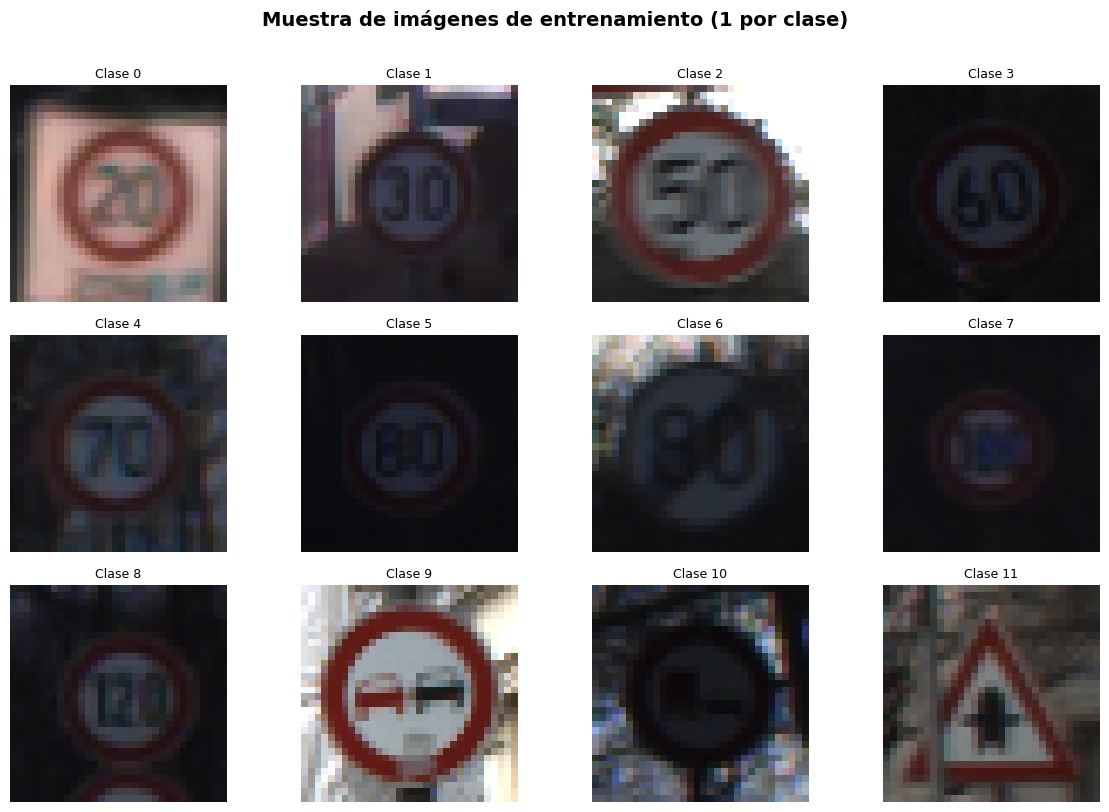

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
fig.suptitle("Muestra de imágenes de entrenamiento (1 por clase)", fontsize=14, fontweight="bold", y=1.01)

for i, ax in enumerate(axes.flat):
    idx = np.where(np.argmax(y_train, axis=1) == i)[0][0]
    ax.imshow(X_train[idx])
    ax.set_title(f"Clase {i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## **<font color="orange">Creación de la Red Neuronal Convolucional</font>**

### **<font color=" #06bbd8">Data Augmentation</font>**

Antes de definir la arquitectura principal, se incorpora un bloque de **aumento de datos** (`data augmentation`) como primera etapa del modelo. Su propósito es generar variaciones artificiales de las imágenes durante el entrenamiento, exponiéndole al modelo a condiciones similares a las que encontraría en escenarios reales: señales ligeramente rotadas, con zoom aplicado, desplazadas o con diferente contraste. Las transformaciones aplicadas son:


| Capa | Efecto |
|------|--------|
| `RandomRotation(0.08)`  | Rotación aleatoria de hasta ~29°|
| `RandomZoom(0.10)`  | Acercamiento o alejamiento de hasta 10% |
| `RandomTranslation(0.10, 0.10)`  | Desplazamiento horizontal y vertical de hasta 10% |
| `RandomContrast(0.10)`  | Variación aleatoria del contraste |

Esto es especialmente valioso en el **GTSRB**, donde las señales aparecen bajo distintas condiciones de iluminación, ángulos de captura y distancias. Al aplicar estas transformaciones solo durante el entrenamiento, el modelo aprende a ser más robusto sin necesidad de recolectar más datos reales.

### **<font color=" #06bbd8">Bloques convolucionales</font>**

La arquitectura sigue un patrón clásico y progresivo de tres bloques convolucionales, cada uno compuesto por dos capas `Conv2D` seguidas de `MaxPooling2D` y `Dropout`.

Las capas `Conv2D` aplican filtros de $3 \times 3$ sobre la imagen para detectar patrones visuales locales. El uso de `padding="same"` preserva las dimensiones espaciales después de cada convolución, evitando pérdida de información en los bordes. La función de activación `ReLU` introduce no-linealidad, permitiendo que el modelo aprenda relaciones complejas entre los píxeles.

El número de filtros se incrementa progresivamente a lo largo de los bloques convolucionales: 32 en el primero, 64 en el segundo y 128 en el tercero. Este diseño responde a un principio fundamental del aprendizaje profundo: las capas tempranas detectan características de bajo nivel como bordes, esquinas y gradientes de color, mientras que las capas más profundas combinan esas representaciones simples para capturar patrones de mayor abstracción, como formas geométricas o símbolos propios de cada clase de señal.

### **<font color=" #06bbd8">Capas de clasificación</font>**

Tras los bloques convolucionales, la capa `Flatten` convierte los mapas de características tridimensionales en un vector unidimensional, preparando la información para las capas densas.

A continuación, una capa `Dense` de 256 neuronas con activación `ReLU` actúa como clasificador intermedio, integrando todas las características aprendidas por las capas convolucionales en una representación compacta. Sobre esta capa se aplica un `Dropout` del **50%** para reducir el sobreajuste..

Finalmente, la capa de salida es una `Dense` de **43 neuronas** (una por cada clase del **GTSRB**) con activación `softmax`, que transforma los valores en una distribución de probabilidad. La clase predicha corresponde a la neurona con mayor probabilidad.

### **<font color=" #06bbd8">Compilación</font>**

El modelo se compila con los siguientes elementos:

- Optimizador `Adam` con tasa de aprendizaje $\eta=0.001$ combina las ventajas de momentum y tasas de aprendizaje adaptativas, siendo una elección robusta para la mayoría de tareas de clasificación con redes profundas.
- Pérdida `categorical_crossentropy`: función de pérdida estándar para problemas de clasificación multi-clase con etiquetas en formato one-hot.
- Métrica `accuracy`: proporción de imágenes clasificadas correctamente, utilizada para monitorear el progreso del entrenamiento.

In [ ]:
# ── Data Augmentation ────────────────────────────────────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# ── Arquitectura CNN ─────────────────────────────────────────────────────────
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.50),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="gtsrb_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "gtsrb_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,603 (3.14 MB)

 Trainable params: 822,603 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

## **<font color="orange">Entrenamiento</font>**

Antes de iniciar el entrenamiento se definen los hiperparámetros principales y los mecanismos de control. Se establece un máximo de **30 épocas** con un tamaño de lote (`batch size`) de **64 imágenes**, lo que significa que los pesos de la red se actualizan después de procesar cada grupo de 64 muestras antes de completar una época completa.

Para evitar un entrenamiento innecesariamente largo, se configuran dos `callbacks`:

- **`EarlyStopping`**: Monitorea la exactitud en el conjunto de validación (`val_accuracy`) y detiene el entrenamiento automáticamente si no hay mejora durante 5 épocas consecutivas. Con el parametro `restore_best_weights=True`, al finalizar el entrenamiento se restauran los pesos correspondientes a la mejor época observada, no los de la última iteración.

- **`ReduceLROnPlateau`**: Vigila la pérdida de validación (`val_loss`) y reduce la tasa de aprendizaje a la mitad (`factor=0.5`) cuando detecta que no hay mejora durante 3 épocas seguidas, con un límite mínimo de $1\times 10^{-6}$
Esto permite que el optimizador realice ajustes más finos cuando el modelo se aproxima a un mínimo, evitando que oscile sin converger.

El método **`model.fit()`** ejecuta el entrenamiento sobre el conjunto de entrenamiento, evaluando el desempeño en cada época sobre el conjunto de validación.

In [ ]:
# ── Callbacks ────────────────────────────────────────────────────────────────
EPOCHS     = 30
BATCH_SIZE = 64

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

print("=" * 52)
print("   Configuración de entrenamiento")
print("=" * 52)
print(f"  Épocas máx.  : {EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Optimizador  : Adam  (lr=0.001)")
print(f"  Loss         : categorical_crossentropy")
print(f"  Early stop   : patience=5  (val_accuracy)")
print(f"  Reduce LR    : patience=3, factor=0.5")
print("=" * 52)
print()

# ── Entrenamiento ─────────────────────────────────────────────────────────────
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

   Configuración de entrenamiento
  Épocas máx.  : 30
  Batch size   : 64
  Optimizador  : Adam  (lr=0.001)
  Loss         : categorical_crossentropy
  Early stop   : patience=5  (val_accuracy)
  Reduce LR    : patience=3, factor=0.5

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.1503 - loss: 3.0921 - val_accuracy: 0.3885 - val_loss: 1.8526 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4229 - loss: 1.7477 - val_accuracy: 0.5592 - val_loss: 1.2482 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5636 - loss: 1.2701 - val_accuracy: 0.7312 - val_loss: 0.7420 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7004 - loss: 0.8628 - val_accuracy: 0.8681 - val_loss: 0.3948 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8056 - loss: 0.5736 - val_accuracy: 0.9463 - val_loss: 0.1697 - learning_rate: 0.0010

## **<font color="orange">Resultados del entrenamiento</font>**

Estos resultados indican que el modelo aprendió a reconocer señales de tránsito con muy alta precisión y, lo más importante, que ese aprendizaje no quedó limitado a las imágenes de entrenamiento sino que se transfirió correctamente a datos nuevos. Con aproximadamente un **0.2%** de error sobre el conjunto de validación, el modelo clasifica correctamente prácticamente todas las señales que no había visto antes, lo cual es el objetivo central de cualquier sistema de reconocimiento de imágenes.

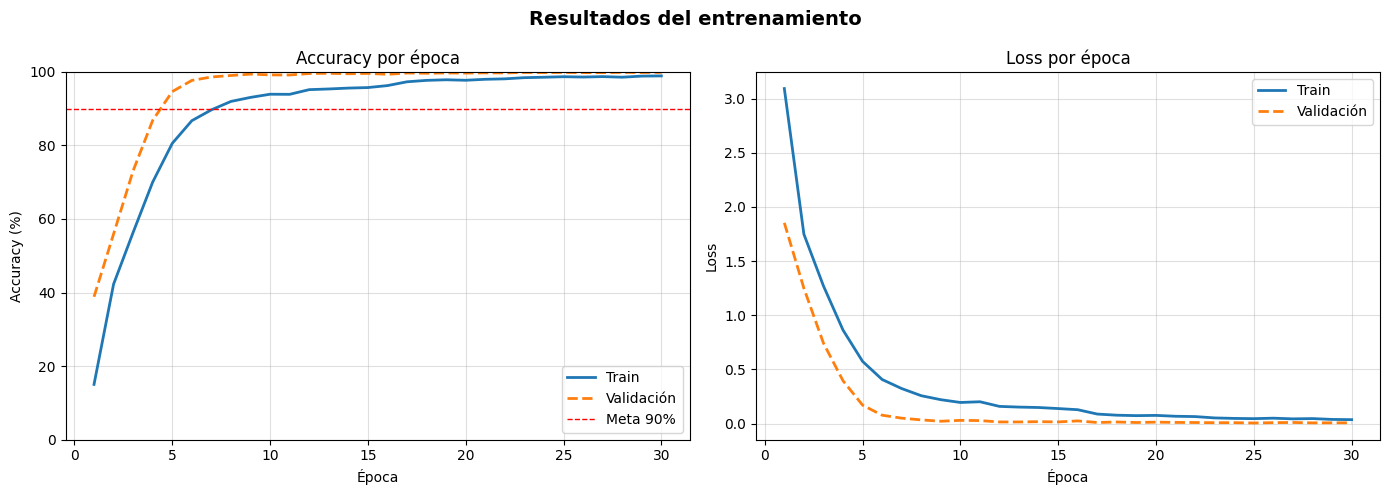

   Resultados finales de entrenamiento
  Épocas ejecutadas : 30
  Train Accuracy    : 98.89%
  Val   Accuracy    : 99.86%
  Train Loss        : 0.0357
  Val   Loss        : 0.0063


In [ ]:
epochs_range = range(1, len(history.history["accuracy"]) + 1)

train_acc  = [v * 100 for v in history.history["accuracy"]]
val_acc    = [v * 100 for v in history.history["val_accuracy"]]
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Resultados del entrenamiento", fontsize=14, fontweight="bold")

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1.plot(epochs_range, train_acc, label="Train",      linewidth=2)
ax1.plot(epochs_range, val_acc,   label="Validación", linewidth=2, linestyle="--")
ax1.axhline(90, color="red", linestyle="--", linewidth=1, label="Meta 90%")
ax1.set_title("Accuracy por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, 100)
ax1.legend()
ax1.grid(alpha=0.4)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2.plot(epochs_range, train_loss, label="Train",      linewidth=2)
ax2.plot(epochs_range, val_loss,   label="Validación", linewidth=2, linestyle="--")
ax2.set_title("Loss por época")
ax2.set_xlabel("Época")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

print("=" * 52)
print("   Resultados finales de entrenamiento")
print("=" * 52)
print(f"  Épocas ejecutadas : {len(epochs_range)}")
print(f"  Train Accuracy    : {train_acc[-1]:.2f}%")
print(f"  Val   Accuracy    : {val_acc[-1]:.2f}%")
print(f"  Train Loss        : {train_loss[-1]:.4f}")
print(f"  Val   Loss        : {val_loss[-1]:.4f}")
print("=" * 52)

## **<font color="orange">Evaluación sobre el conjunto de validación</font>**

De las **7,842** imágenes evaluadas, el modelo cometió pocos errores, lo que se traduce en una exactitud del **99.89%**. Lo destacable es que ese rendimiento se mantiene de forma uniforme a lo largo de las 43 clases del dataset: las métricas macro (que evalúan cada clase con el mismo peso sin importar cuántas imágenes tenga) superan el **99.8%** en todos los casos. Esto significa que el modelo reconoce con igual precisión tanto las clases con cientos de imágenes como aquellas con apenas 42 o 48 muestras.


── Classification Report ─────────────────────────
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      0.99      1.00       444
           2       1.00      1.00      1.00       450
           3       1.00      1.00      1.00       282
           4       1.00      1.00      1.00       396
           5       1.00      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       0.99      1.00      0.99       288
           8       1.00      1.00      1.00       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      1.00      1.00       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00      1.00      1.00       126
          16       1.00      

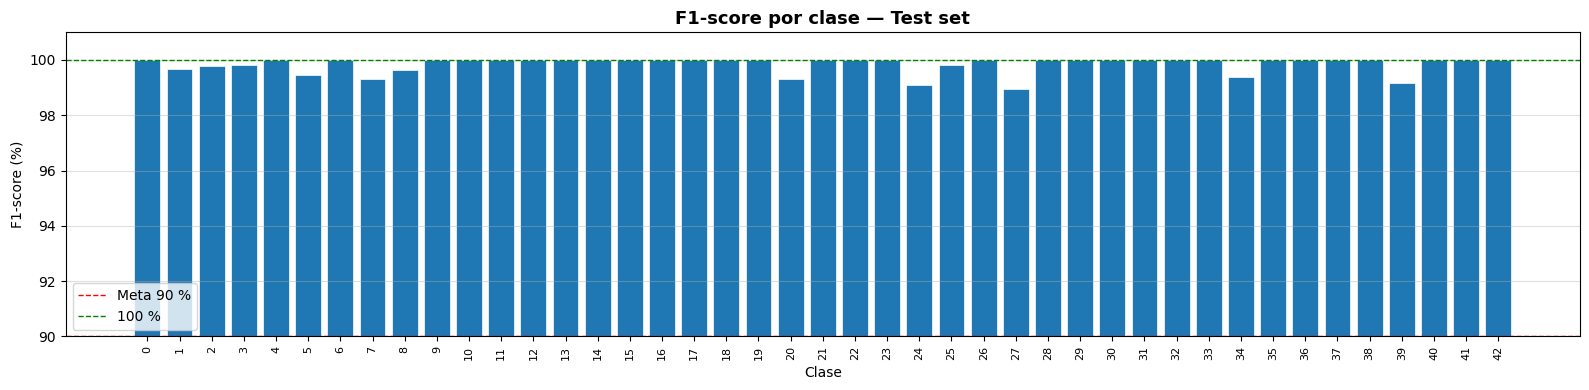

In [ ]:
class_names  = [str(i) for i in range(NUM_CLASSES)]
class_to_idx = {str(i): i for i in range(NUM_CLASSES)}

y_pred_probs = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

report_dict = classification_report(y_true, y_pred, output_dict=True)
report_text = classification_report(y_true, y_pred)

print("\n── Classification Report ─────────────────────────")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0,
))

plot_f1_by_class(report_dict, "F1-score por clase — Test set")


## **<font color="orange">Guardado del modelo y metadatos</font>**

Una vez que el modelo ha terminado de entrenarse, se procede a realizar respaldo de todo lo necesario para estar en posibilidad de realizar un reentrenamiento sin tener que repetir el proceso desde cero. Para ello, se crea una carpeta llamada checkpoint donde se almacenan tres archivos.

El primero es `model.keras`, que guarda el modelo completo tal como quedó al final del entrenamiento: su arquitectura, los pesos que aprendió y el estado del optimizador. Con este archivo es posible cargar el modelo en cualquier momento y usarlo directamente para clasificar nuevas imágenes.

El segundo es `history.json`, que registra cómo evolucionaron la pérdida y la exactitud a lo largo de cada época, tanto en entrenamiento como en validación. Este archivo es útil para graficar las curvas de aprendizaje y analizar el comportamiento del modelo durante el entrenamiento.

El tercero es `meta.json`, que almacena información de contexto sobre el experimento: el número de clases, el tamaño de las imágenes, cuántas épocas se ejecutaron realmente y cuál fue la mejor exactitud de validación alcanzada.

Estos tres archivos forman un respaldo completo del experimento que permite retomar el trabajo en cualquier momento sin depender de que los datos originales estén disponibles.

In [ ]:
CHECKPOINT_DIR = "checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

model.save(os.path.join(CHECKPOINT_DIR, "model.keras"))

with open(os.path.join(CHECKPOINT_DIR, "history.json"), "w") as f:
    json.dump(history.history, f, indent=2)

class_names  = [str(i) for i in range(NUM_CLASSES)]
class_to_idx = {str(i): i for i in range(NUM_CLASSES)}

meta = {
    "class_names":    class_names,
    "class_to_idx":   class_to_idx,
    "NUM_CLASSES":    NUM_CLASSES,
    "IMG_SIZE":       IMG_SIZE,
    "epochs_trained": len(history.history["loss"]),
    "best_val_acc":   float(max(history.history["val_accuracy"])),
}
with open(os.path.join(CHECKPOINT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("=" * 52)
print("   Checkpoint guardado")
print("=" * 52)
print(f"  Directorio       : {CHECKPOINT_DIR}/")
print(f"  model.keras      — modelo + optimizador")
print(f"  history.json     — métricas por época")
print(f"  meta.json        — clases y configuración")
print("=" * 52)
print(f"  Épocas entrenadas : {meta['epochs_trained']}")
print(f"  Mejor val_acc     : {meta['best_val_acc']:.4f}")

   Checkpoint guardado
  Directorio       : checkpoint/
  model.keras      — modelo + optimizador
  history.json     — métricas por época
  meta.json        — clases y configuración
  Épocas entrenadas : 30
  Mejor val_acc     : 0.9986


## **<font color="#06bbd8">Carga del modelo</font>**

Para continuar el análisis sin necesidad de reentrenar, se recuperan todos los elementos guardados previamente en la carpeta checkpoint. En esta celda se prueba la funcionalidad de carga del modelo: se restaura desde el archivo `model.keras` y se recompila con la misma configuración de optimizador y función de pérdida, verificando que el proceso de guardado funcionó correctamente y que el modelo puede ser recuperado en cualquier momento para ser utilizado en producción o para continuar su evaluación.

Se leen los archivos `history.json` y `meta.json`, recuperando respectivamente el historial de métricas por época y los metadatos del experimento, de modo que el resto del notebook pueda funcionar exactamente igual que si el entrenamiento acabara de completarse.

Finalmente, se imprime un resumen de verificación que confirma que el checkpoint fue cargado correctamente, mostrando los parámetros clave del experimento y la arquitectura del modelo.

In [ ]:
CHECKPOINT_DIR = "checkpoint"

model = keras.models.load_model(os.path.join(CHECKPOINT_DIR, "model.keras"))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

with open(os.path.join(CHECKPOINT_DIR, "history.json"), "r") as f:
    history_data = json.load(f)

with open(os.path.join(CHECKPOINT_DIR, "meta.json"), "r") as f:
    meta = json.load(f)

# Restaurar variables de configuración al namespace global
NUM_CLASSES = meta["NUM_CLASSES"]
IMG_SIZE    = meta["IMG_SIZE"]
CHANNELS    = 3
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, CHANNELS)
class_names  = meta["class_names"]
class_to_idx = meta["class_to_idx"]


epochs_done  = meta["epochs_trained"]
best_val_acc = meta["best_val_acc"]

print("=" * 52)
print("   Checkpoint cargado exitosamente")
print("=" * 52)
print(f"  Directorio        : {CHECKPOINT_DIR}/")
print(f"  Clases            : {NUM_CLASSES}")
print(f"  Tamaño de imagen  : {IMG_SIZE}×{IMG_SIZE}×{CHANNELS}")
print(f"  Épocas entrenadas : {epochs_done}")
print(f"  Mejor val_acc     : {best_val_acc:.4f}")
print("=" * 52)
print()

print("── Arquitectura cargada ──────────────────────────")
model.summary(line_length=52)

   Checkpoint cargado exitosamente
  Directorio        : checkpoint/
  Clases            : 43
  Tamaño de imagen  : 32×32×3
  Épocas entrenadas : 30
  Mejor val_acc     : 0.9986

── Arquitectura cargada ──────────────────────────


Model: "gtsrb_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape   ┃  Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ data_augmentation    │ (None, 32, 32, │        0 │
│ (Sequential)         │ 3)             │          │
├──────────────────────┼────────────────┼──────────┤
│ conv2d (Conv2D)      │ (None, 32, 32, │      896 │
│                      │ 32)            │          │
├──────────────────────┼────────────────┼──────────┤
│ conv2d_1 (Conv2D)    │ (None, 32, 32, │    9,248 │
│                      │ 32)            │          │
├──────────────────────┼────────────────┼──────────┤
│ max_pooling2d        │ (None, 16, 16, │        0 │
│ (MaxPooling2D)       │ 32)            │          │
├──────────────────────┼────────────────┼──────────┤
│ dropout (Dropout)    │ (None, 16, 16, │        0 │
│                      │ 32)            │          │
├──────────────────────┼────────────────┼──────────┤
│ conv2d_2 (Conv2D)    │ (None, 16, 16, │   18,496 │
│                      │ 64)            │          │
├──────────────────────┼────────────────┼──────────┤
│ conv2d_3 (Conv2D)    │ (None, 16, 16, │   36,928 │
│                      │ 64)            │          │
├──────────────────────┼────────────────┼──────────┤
│ max_pooling2d_1      │ (None, 8, 8,   │        0 │
│ (MaxPooling2D)       │ 64)            │          │
├──────────────────────┼────────────────┼──────────┤
│ dropout_1 (Dropout)  │ (None, 8, 8,   │        0 │
│                      │ 64)            │          │
├──────────────────────┼────────────────┼──────────┤
│ conv2d_4 (Conv2D)    │ (None, 8, 8,   │   73,856 │
│                      │ 128)           │          │
├──────────────────────┼────────────────┼──────────┤
│ conv2d_5 (Conv2D)    │ (None, 8, 8,   │  147,584 │
│                      │ 128)           │          │
├──────────────────────┼────────────────┼──────────┤
│ max_pooling2d_2      │ (None, 4, 4,   │        0 │
│ (MaxPooling2D)       │ 128)           │          │
├──────────────────────┼────────────────┼──────────┤
│ dropout_2 (Dropout)  │ (None, 4, 4,   │        0 │
│                      │ 128)           │          │
├──────────────────────┼────────────────┼──────────┤
│ flatten (Flatten)    │ (None, 2048)   │        0 │
├──────────────────────┼────────────────┼──────────┤
│ dense (Dense)        │ (None, 256)    │  524,544 │
├──────────────────────┼────────────────┼──────────┤
│ dropout_3 (Dropout)  │ (None, 256)    │        0 │
├──────────────────────┼────────────────┼──────────┤
│ dense_1 (Dense)      │ (None, 43)     │   11,051 │
└──────────────────────┴────────────────┴──────────┘

 Total params: 822,603 (3.14 MB)

 Trainable params: 822,603 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

### **<font color=" #06bbd8">Evaluación sobre el conjunto de validación</font>**

Sobre las 12,630 imágenes del conjunto de prueba oficial, el modelo alcanzó una exactitud del **95.36%**, clasificando incorrectamente 586 imágenes. Lo relevante de estos resultados es la diferencia en confianza entre predicciones correctas e incorrectas: en los aciertos, el modelo asigna una probabilidad promedio del **98.70%** a la clase predicha, mientras que en los errores esa confianza desciende al **74.82%**. Este comportamiento sugiere que el modelo tiende a dudar cuando se equivoca, en lugar de hacerlo con total seguridad, lo que es una señal positiva sobre su capacidad para reconocer cuándo una imagen le resulta difícil de clasificar.


In [ ]:
test_df = pd.read_csv(os.path.join(DATASET_PATH, "Test.csv"))

print(f"Imágenes en Test.csv : {len(test_df)}")
print(f"Clases únicas        : {test_df['ClassId'].nunique()}")
print()

def load_and_preprocess(row, dataset_path, img_size):
    img_path = os.path.join(dataset_path, row["Path"])
    img = Image.open(img_path).convert("RGB")

    # Recortar por bounding box ROI (misma región que se usó al entrenar)
    img = img.crop((
        row["Roi.X1"],
        row["Roi.Y1"],
        row["Roi.X2"],
        row["Roi.Y2"],
    ))

    img = img.resize((img_size, img_size), Image.LANCZOS)
    return np.array(img, dtype=np.float32) / 255.0


X_test = np.zeros((len(test_df), IMG_SIZE, IMG_SIZE, CHANNELS), dtype=np.float32)
load_errors = []

for i, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Cargando imágenes"):
    try:
        X_test[i] = load_and_preprocess(row, DATASET_PATH, IMG_SIZE)
    except Exception as e:
        load_errors.append((i, row["Path"], str(e)))

y_test = test_df["ClassId"].values

print("=" * 52)
print("   Test set listo")
print("=" * 52)
print(f"  X_test shape : {X_test.shape}")
print(f"  y_test shape : {y_test.shape}")
print(f"  Rango valores: [{X_test.min():.3f}, {X_test.max():.3f}]")
print(f"  Errores carga: {len(load_errors)}")
if load_errors:
    for idx, path, err in load_errors:
        print(f"    ✗ [{idx}] {path} → {err}")
print("=" * 52)

Imágenes en Test.csv : 12630
Clases únicas        : 43



Cargando imágenes:   0%|          | 0/12630 [00:00<?, ?it/s]

   Test set listo
  X_test shape : (12630, 32, 32, 3)
  y_test shape : (12630,)
  Rango valores: [0.000, 1.000]
  Errores carga: 0


In [ ]:

_ = model.predict(X_test[:1], verbose=0)

y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)


y_pred_probs = model.predict(X_test, batch_size=64, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_confidence = np.max(y_pred_probs, axis=1)

correct   = y_pred == y_test
n_correct = correct.sum()
n_wrong   = (~correct).sum()

conf_correct = y_confidence[correct].mean()
conf_wrong   = y_confidence[~correct].mean() if n_wrong > 0 else float("nan")

print("=" * 52)
print("   Evaluación en Test Set")
print("=" * 52)
print(f"  Loss              : {test_loss:.4f}")
print(f"  Accuracy          : {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"  Imágenes totales  : {len(y_test)}")
print(f"  Correctas         : {n_correct}")
print(f"  Incorrectas       : {n_wrong}")
print(f"  Confianza aciertos: {conf_correct:.4f}")
print(f"  Confianza errores : {conf_wrong:.4f}")
print("=" * 52)

   Evaluación en Test Set
  Loss              : 0.2235
  Accuracy          : 0.9536  (95.36 %)
  Imágenes totales  : 12630
  Correctas         : 12044
  Incorrectas       : 586
  Confianza aciertos: 0.9870
  Confianza errores : 0.7482



── Classification Report ─────────────────────────
              precision    recall  f1-score   support

           0       0.49      1.00      0.66        60
           1       0.87      0.99      0.93       720
           2       0.96      0.96      0.96       750
           3       0.96      0.92      0.94       450
           4       1.00      0.93      0.96       660
           5       0.94      0.94      0.94       630
           6       0.98      0.95      0.97       150
           7       0.99      0.91      0.95       450
           8       0.98      0.86      0.92       450
           9       0.99      0.98      0.99       480
          10       1.00      1.00      1.00       660
          11       0.98      1.00      0.99       420
          12       1.00      0.93      0.96       690
          13       0.95      1.00      0.97       720
          14       1.00      1.00      1.00       270
          15       1.00      1.00      1.00       210
          16       0.99      

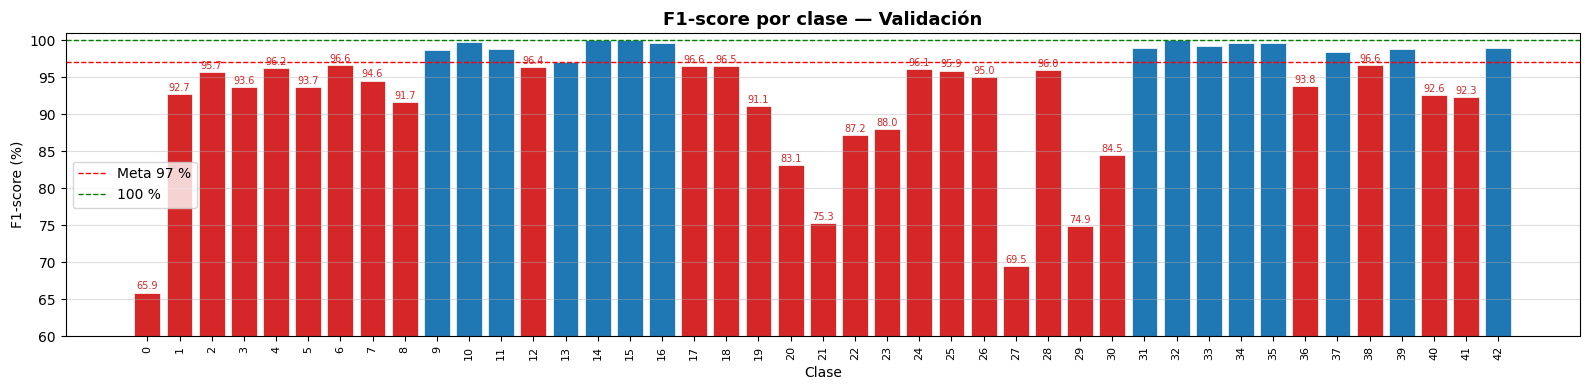

In [ ]:
reporte_val = classification_report(
    y_test, y_pred,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

# Print legible en consola
print("\n── Classification Report ─────────────────────────")
print(classification_report(
    y_test, y_pred,
    target_names=class_names,
    zero_division=0,
))

plot_f1_by_class(reporte_val, "F1-score por clase — Validación", umbral=0.97)

### **<font color=" #06bbd8">La matriz de confusión</font>**

La matriz de confusión permite visualizar en detalle cómo distribuye el modelo sus predicciones a lo largo de las 43 clases. En la matriz completa (izquierda) se aprecia que la diagonal principal concentra prácticamente todos los valores, confirmandose alto rendimiento global del modelo: la mayoría de las señales son clasificadas en su categoría correcta sin confundirse con otras.

El gráfico de la derecha amplía el análisis mostrando las 10 clases con mayor número de errores. En general, los errores son escasos y se distribuyen entre muy pocas predicciones incorrectas por clase, lo que es consistente con el alto rendimiento global del modelo. Este tipo de confusiones puntuales son esperables en un dataset como el **GTSRB**, donde varias señales comparten forma, color y estructura general, diferenciándose únicamente en detalles internos que pueden ser difíciles de capturar en imágenes de $32 \times 32$ píxeles.

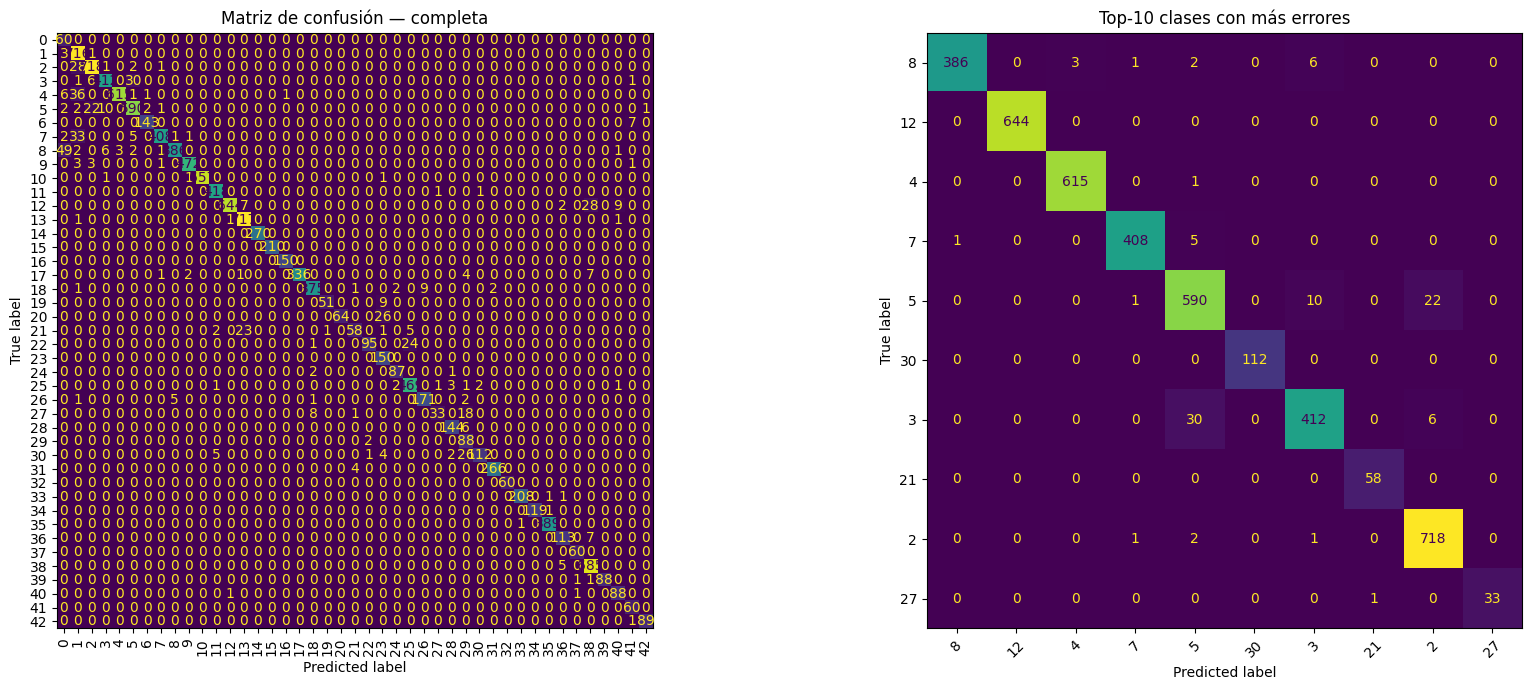

In [ ]:
cm   = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False, xticks_rotation=90)
axes[0].set_title("Matriz de confusión — completa")

errors_per_class = cm.sum(axis=1) - np.diag(cm)
top10_idx        = np.argsort(errors_per_class)[::-1][:10]
cm_top10         = cm[np.ix_(top10_idx, top10_idx)]
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_top10,
    display_labels=[class_names[i] for i in top10_idx],
)
disp2.plot(ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title("Top-10 clases con más errores")

plt.tight_layout()
plt.show()


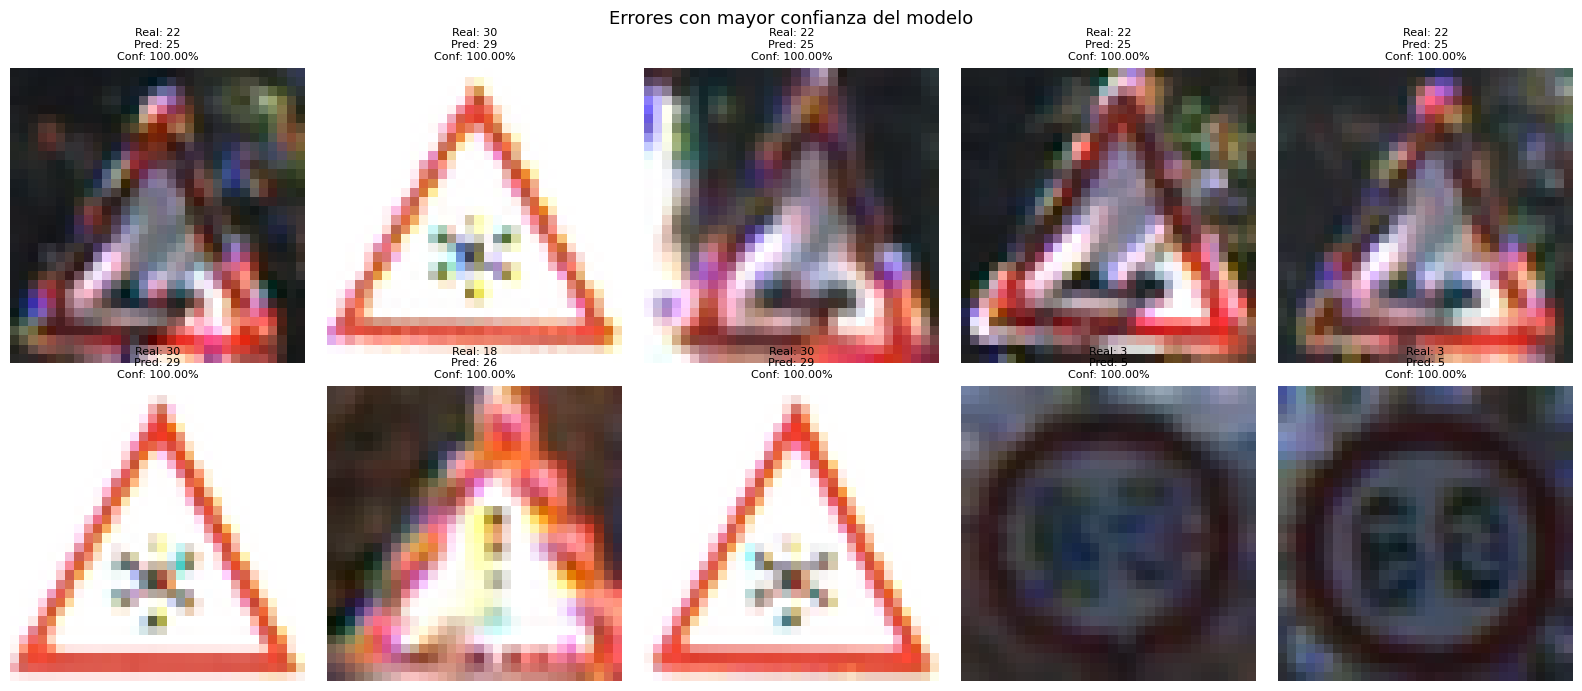

In [ ]:
wrong_idx = np.where(~correct)[0]

if len(wrong_idx) > 0:

    wrong_conf      = y_confidence[wrong_idx]
    sorted_wrong    = wrong_idx[np.argsort(wrong_conf)[::-1]]
    top_wrong       = sorted_wrong[:10]

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle("Errores con mayor confianza del modelo", fontsize=13)

    for ax, idx in zip(axes.flat, top_wrong):
        ax.imshow(X_test[idx])
        ax.set_title(
            f"Real: {class_names[y_test[idx]]}\n"
            f"Pred: {class_names[y_pred[idx]]}\n"
            f"Conf: {y_confidence[idx]:.2%}",
            fontsize=8,
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("\n✓ Sin errores en el test set.")

# **<font color="orange">Referencias</font>**

* Houben, S. (s.f.). GTSRB - German Traffic Sign Recognition Benchmark [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

* Stallkamp, J., Schlipsing, M., Salmen, J., & Igel, C. (2011). The German Traffic Sign Recognition Benchmark: A multi-class classification competition. ResearchGate. https://www.researchgate.net/publication/224260296_The_German_Traffic_Sign_Recognition_Benchmark_A_multi-class_classification_competition

* Nair, B., Ranjan, S., & Senthamilarasu, S. (2020). *Applied deep learning and computer vision for self-driving cars*. Packt Publishing. https://learning.oreilly.com/library/view/applied-deep-learning/9781838646301/

* Surmenok, P. (s.f.). GTSRB [Repositorio de código]. GitHub. https://github.com/surmenok/GTSRB

Declaración de uso de inteligencia artificial Anthropic. (2026). Claude (claude-sonnet-4-6) [Modelo de lenguaje grande], utilizado para refinamiento de código de python https://claude.ai

<center>

**Equipo 01 • Tecnológico de Monterrey • 2026**

</center>